In [ ]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMassage], operator.add]


In [ ]:
class AgentState(TypedDict):
  input: str
  chat_history: list[BaseMessage]
  agent_outcome: Union[AgentAction, AgentFinish, None]
  intermediate_steps: Annotated[list[tuple[AgentAction, str]], operator.add]


In [1]:
%pip install -U google-generativeai
%pip install google-ai-generativelanguage==0.6.15
%pip install -U langchain-google-genai
%pip install -U langchain-community
%pip install -U langgraph
%pip install -U langgraph langchain-community
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Thiago\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Thiago\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Thiago\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Thiago\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Thiago\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
%pip install google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Thiago\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator

import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage

from langchain_community.tools.tavily_search import TavilySearchResults

C:\Users\Thiago\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Thiago\AppData\Local\Temp\ipykernel_15560\653529683.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [11]:
import os
from dotenv import load_dotenv
from google import genai

load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0,
    google_api_key=os.getenv("GEMINI_API_KEY")
)


os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [5]:
tool = TavilySearchResults(max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


C:\Users\Thiago\AppData\Local\Temp\ipykernel_15560\1287549681.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=4)


In [6]:
class AgentState(TypedDict):
    messages: Annotated[List[AnyMessage], operator.add]

In [7]:
class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:
                print("\n ....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [12]:
prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0,
    google_api_key=os.getenv("GEMINI_API_KEY")
)

abot = Agent(model, [tool], system=prompt)

In [13]:
mermaid_code = abot.graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



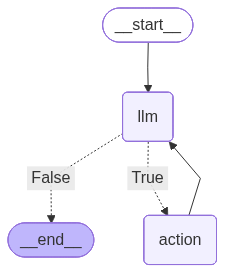

In [14]:
from IPython.display import Image, display

try:
    
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))

except Exception as e:
    print(f"Erro ao tentar gerar PNG do Mermaid: {e}")
    print("\nCertifique-se de que a sua versão do LangGraph possui o método `.draw_mermaid_png()`.")
    print("Como alternativa, use `.draw_mermaid()` para obter a string e visualizar externamente.")

In [15]:
%pip install -U langchain-tavily

   ---------------------------------------- 0.0/112.7 kB ? eta -:--:--
   ---------------------------------------- 112.7/112.7 kB 3.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Thiago\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]

class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t_call in tool_calls:
            print(f"Calling tool: {t_call['name']} with args: {t_call['args']}")
            if t_call['name'] not in self.tools:
                print("\n ....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t_call['name']].invoke(t_call['args'])
            results.append(ToolMessage(tool_call_id=t_call['id'], name=t_call['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

NameError: name 'BaseMessage' is not defined

In [17]:
prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""
model_instance = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tool_instance = TavilySearchResults(max_results=4)

abot = Agent(model_instance, [tool_instance], system=prompt)

messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")]

print("Iniciando interação do agente:")
final_result_state = None

for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "tempo em S\\u00e3o Paulo hoje"}'}, '__gemini_function_call_thought_signatures__': {'c5d7c566-dd41-41d5-86d1-d7eeefd0a831': 'Cv0BAb4+9vtxgjsB4gBpWhYPZEMLzDpUf9Ky7AdSddZz6qrbezv+FVSpQz/bhwy+/Q1F/+OuWPHe/GfIGOgiqGl5W47Lj/oQkB8dS4J9P305C4oDFZPGquQKq16Wl/dxsLNl6fdEPuO3sCLvqh0zXQY4M3Mg60o9TzTdCn5pLQ/iwM+i56gMG6h500qPLJxiplLlsctkzrbyEbX+62HW3lc0yGQEcp8e2OeE8Nb28eTAMM11YaX9QUi0ZYGbGMl9QbnCeBGciNpAB5iOVyN9PQy8RtWCJEdsHnG5lJB4wR2ucwz2Rgo4dF/6knB0kK4A7NmYHR+azpqY5oCM6jFM6g=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d54c1-a5ee-7e51-bdb3-265e31810704-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'tempo em São Paulo hoje'}, 'id': 'c5d7c566-dd41-41d5-86d1-d7eeefd0a831', 'type': 'tool_call'}]

In [21]:
from datetime import date
current_date = date.today().strftime("%d/%m/%Y") # Formato dd/mm/aaaa

prompt = f"""Você é um assistente de pesquisa inteligente e altamente atualizado. \
Sua principal prioridade é encontrar as informações mais RECENTES e em TEMPO REAL sempre que possível. \
A data atual é {current_date}. \
Ao buscar sobre o tempo ou eventos que se referem a "hoje" ou "agora", \
você DEVE **incluir a data atual '{current_date}' na sua consulta para a ferramenta de busca**. \
Por exemplo, se a pergunta é "tempo em cidade x hoje", a consulta para a ferramenta deve ser "tempo em cidade x {current_date}". \
Ignore ou descarte informações que claramente se refiram a datas passadas ou futuras ao responder perguntas sobre "hoje". \
Use o mecanismo de busca para procurar informações, sempre buscando o 'hoje' ou o 'agora' quando o contexto indicar. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
""" 

model_instance = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tool_instance = TavilySearchResults(max_results=4)
abot = Agent(model_instance, [tool_instance], system=prompt)

user_query = "Como está o tempo em São Paulo hoje?"

messages = [HumanMessage(content=user_query)]

print("Iniciando interação do agente:")
final_result_state = None
for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "tempo em S\\u00e3o Paulo 03/04/2026"}'}, '__gemini_function_call_thought_signatures__': {'dbfab1cb-f9a1-4110-8e20-2ea586cefe7e': 'CrcCAb4+9vsvQWtRyrTHyGi0/wVuGDuvfOBcutvC/VDAvz1klaP24oBBnKZ7IF9FSMCvtg0doiXGwSH+iYJtcyzi2N7WzPSAEhLk7t7uyV0NQjOInwthrZu2uYgMZkzJSXkeeys6+3vlXgQHYJChh0yOavQwIIrT3mCJhDexHsyc+NzF1ZwNdPd77Vd2rhd1NUankOBtDyiG9V5ZlwSPwrR+omTWM7WEaIbhtaNCbK/VkcCFW/59Wpqg9HZBcRSiurQXD8kA5Q1PghIhndclWhML7gYKm9e5uwBlLwHoI3zQ3yKRTm0tBQsfLJ9itY3a2RtXEg7JtAKs0xE7FjnRZEfGwC3v1im/FMb3KjWg8lQbEAfw7AfDH7Vwidx+HOyjgeL6DMbHSVtcSmMHu3k6TfYgvdTWMjZl/Mg='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d54c8-dd6d-7670-97ff-ef38fad11a83-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'tempo em São

In [ ]:

user_query_tomorrow = "Como está o tempo em São Paulo amanhã?" #atualizamos apenas a pergunta do usuário

messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando interação do agente para amanhã ---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final para amanhã ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado para amanhã.")

In [ ]:
from langchain_core.messages import HumanMessage

user_query_tomorrow = "Como foi o tempo em São Paulo ontem?" 

messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando interação do agente ---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final  ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Então, vamos chamar novamente este agente, perguntando: "Qual é o tempo em SP hoje? Dessa vez, vamos olhar em detalhes o que o agente buscou e como ele o fez.

In [19]:
messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")] 
result = abot.graph.invoke({"messages": messages}) 

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'tempo em São Paulo hoje'}, 'id': '9a8ed48e-296b-441d-a907-c61b0af4fd38', 'type': 'tool_call'}
Back to the model!


In [20]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'O tempo em São Paulo hoje, 23 de março, está com previsão de sol e aumento de nuvens a partir da tarde, sem chuva. A temperatura máxima esperada é de 29°C e a mínima de 19°C. A sensação térmica pode chegar a 22°C.\n\nNo momento (considerando o horário da consulta, que é por volta das 20:00), está nublado, com temperatura de 22°C e sensação térmica de 22°C, com vento fraco do sul. A umidade está em torno de 58% e não há previsão de chuva.',
  'extras': {'signature': 'CuoLAb4+9vu4KcbCOaQzYfE1ahuW+vCvxOICiHA5M+4mYTRWIukxBWO0tRgNxgZ7VVbnHoKlWGoJShm61icu30u2yz9Xm9M+2I28coquRQ+4dbC5Daaah0JBtzJZ4zh2b7IJUFv1+nfXLG5H/ChRg+zX7iTEiKKs7t73HDLG1Wfm4fvuQb3wLm0G49RJlg6VoNK9nS1cr4SsbE1E+eNjRIa9WGnUQKLVoMXe0zmMBjVvE4jVVrMAi4X+ZvqzF6ysopeMZnAKyv3LI8vtqjPB8BF45AkvTGGZhX/1rbu7q0JZzt3VSk3FrE9WtTRhy0HjtMzQUGGVLGcjfKBMBaBBAcKLgb66Pkc4dT5rDFNOpuXjYP7FRFc7qL95D57IU4ymzI6W+Z0YsOwMi/L4/F4vbihFh4biq7XEU2KwAUcRVJIAn1MMWXos/N9xDa+UFFYZa7bB0kFGi1ST51iB5jYoUtkKx/bdkGKo6v/aIJ7TZH15+dFAEkD+

In [22]:
messages = [HumanMessage(content="Como está o tempo em São Paulo e no Rio de Janeiro hoje?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'tempo em São Paulo 03/04/2026'}, 'id': '0e90568f-8bf2-4ab6-9990-f4779c927597', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'tempo no Rio de Janeiro 03/04/2026'}, 'id': 'f069ed7a-878a-4739-84e4-f0b2166e3765', 'type': 'tool_call'}
Back to the model!


In [23]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'Em São Paulo, hoje, 03/04/2026, a previsão indica temperaturas em torno de 26°C a 30°C, com mínimas de 18°C a 19°C. Há possibilidade de chuva irregular e o tempo pode variar entre sol intenso com nuvens dispersas e períodos de chuva moderada, com baixa precipitação (cerca de 0.3 mm).\n\nNo Rio de Janeiro, hoje, 03/04/2026, as temperaturas estarão elevadas, com máximas de 32°C (sensação térmica de até 37°C) e mínimas de 23°C. O dia terá períodos de sol, mas também há previsão de chuvas leves a moderadas, especialmente à tarde e à noite, com umidade variando entre 58% e 85%.',
  'extras': {'signature': 'CqkLAb4+9vtiUkxTpAyvkkSEe9lrwXo92qyDGDOgP3OsUa15K4NSyMLn0kHs+0ojpSfK93jy0VSG2xnj7gcPbOS1um1LaXx24tgQ8jtKxDYvsimAJ2g174IHkSESCQKM2wEmdmmX1IxpI5FZuuGQN0skSIPPd5FmzPAGJ/MursnOy7S2uNjFlB/ElOdMWuVOjkJ//2cMU9qCqru8Gq8v+WFyp7n5CJQqAes536GSGmd43aEB8Kpek8uVZOi8gsyu939abaPZs1/WoI6T0Gy6c0ZPougIZO3+IjqkdpnJrGvk3JlTp9pfa2zCW8uNnsNfZV/Jv/Zm55BIwqTkJaCYv4m0+WAAu5aRebsI6JyUYO

In [24]:
query_passado = "Qual país sediou a Copa do Mundo de futebol em 1998? Quem foi o campeão e qual o placar da final? \
Qual era o Produto Interno Bruto (PIB) desse país no ano da Copa e qual é o PIB atual (últimos dados disponíveis, como 2023 ou 2024)? \
Qual a capital desse país e qual sua moeda atual? Responda a cada pergunta separadamente."
messages = [HumanMessage(content=query_passado)]

print("\nIniciando interação do agente para pergunta sobre o passado:")

current_state = {}
for s in abot.graph.stream({"messages": messages}):
    current_state.update(s)
    print(s)
    print("---")

print("\n--- Resultado Final para o Passado ---")
if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
    final_message_content = current_state['llm']['messages'][-1].content
    print(final_message_content)
else:
    print("Nenhum resultado final ou resultado inesperado. Verifique os logs acima.")



Iniciando interação do agente para pergunta sobre o passado:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "Copa do Mundo 1998 sede"}'}, '__gemini_function_call_thought_signatures__': {'41a63420-49a8-4f43-9712-d9e71fa6586c': 'CpkGAb4+9vuIFOHRpx8GpYLrjZm9cnpqs6oEyVjoozacqXldoq5oaUBWf8lkxVZRp8HzcrOR7Hy7bti3A0/l4reWUhreZ2FQkEsTjB9YfnZPW8cvm5CnI9Izqv5/ZtXRHtgJmCWw7plZ5ZW5FwfjHPGPUSotVp3Ut+nOc6exm02yjyIhuBkuZYig/g1JdwAlq5bsMu8/iZcdsUEMEiuph+pjZB1xB3yS+6iWJzGT0TXGsnJ+nusyfxGJHwhCSC44UPv1S4ZR5C+t9ySCeCxGzXHhW1BrIBlMH1yMB3ikSrTTq+JDaLjMf3EJy5JgfSiAgccyHZ+XiDgMtxtYLGxDB3ptbESTp6/JixVKh/O81J/EByiGtW48HuxN5E1jLTgQI3P+d3eCYTJ0H6B7k+XH8FzxLL5B2OfVhE2gcrzE7epgTqWQFt3JrtxdK8hFek2Ae0Qxz09DfSRX9pBJlGK/bRGh9Tqv9eIlNggTHUPUZ4JkSN1vpDoXIxs44JArqr96FSg4RLyvOfLPbt1sK7it/AmaeTbD2BJBeBvmjVdwkRZrMnm5foxpBQgO7mjErnLZ6g1sOfXa8re1h4nuZY18C1V1J4dlSOwNPx+0DDCK0O7eVpSqP3gxT1zAz5kPXspxAXZ0aLBzZLQgfxc2SuWkCPMHX+mCjyC6jL9X

In [25]:
print("\n--- Agente de Pesquisa Interativo ---")
print("Digite sua pergunta ou 'sair' para encerrar.")

while True:
    user_input = input("\nVocê: ") 
    if user_input.lower() == "sair":
        print("Agente: Encerrando a conversa. Até logo!")
        break

    messages = [HumanMessage(content=user_input)]

    print("Agente: Pensando e buscando...")
    final_result_state = None
    try:

        current_state = {}
        for s in abot.graph.stream({"messages": messages}):
            current_state.update(s)

        print("\nAgente:")

        if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
            final_message = current_state['llm']['messages'][-1]
            if hasattr(final_message, 'content'):
                print(final_message.content)
            else:
                print("Não foi possível extrair o conteúdo da resposta final do LLM.")
        else:
            print("Não foi possível obter uma resposta do agente para esta pergunta.")

    except Exception as e:
        print(f"Agente: Ocorreu um erro durante a execução: {e}")
        print("Tente novamente ou digite 'sair'.")

print("\n--- Conversa Encerrada ---")


--- Agente de Pesquisa Interativo ---
Digite sua pergunta ou 'sair' para encerrar.
Agente: Pensando e buscando...

Agente:
[{'type': 'text', 'text': 'Ser um bom namorado envolve uma combinação de qualidades e ações que demonstram amor, respeito e apoio. Aqui estão algumas dicas:\n\n*   **Comunicação Aberta e Honesta:**\n    *   Expresse seus sentimentos e pensamentos de forma clara e respeitosa.\n    *   Ouça ativamente o que sua namorada tem a dizer, sem interromper ou julgar.\n    *   Esteja disposto a conversar sobre problemas e encontrar soluções juntos.\n\n*   **Respeito:**\n    *   Respeite as opiniões, sentimentos, limites e individualidade dela.\n    *   Valorize o tempo e o espaço dela.\n    *   Trate-a com dignidade e nunca a menospreze.\n\n*   **Apoio:**\n    *   Esteja lá para ela nos bons e maus momentos.\n    *   Incentive-a a perseguir seus sonhos e objetivos.\n    *   Celebre suas conquistas e ofereça conforto em suas dificuldades.\n\n*   **Carinho e Afeto:**\n    *   

C:\Users\Thiago\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\langchain_google_genai\chat_models.py:2858: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


Agente: Pensando e buscando...
Agente: Ocorreu um erro durante a execução: contents are required.
Tente novamente ou digite 'sair'.
Agente: Pensando e buscando...
Agente: Ocorreu um erro durante a execução: contents are required.
Tente novamente ou digite 'sair'.
Agente: Encerrando a conversa. Até logo!

--- Conversa Encerrada ---
